In [1]:
import os
import sys
import torch
from torchvision import transforms
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F

sys.path.append(os.path.abspath(os.path.join("../..")))
from src.datasets.generateddataset import GeneratedDataset
from src.transformation.randomelastictransform import RandomElasticTransform

In [2]:
dataset = GeneratedDataset(
    root_dir="/nfs/home/tpz8688/Captcha-Recognition/data/generated", 
    # transform=captcha_transformation, 
    preload=False # TODO: Set to true to get best possible performance on training
)

In [20]:
raw_image, label, label_len = dataset[3]

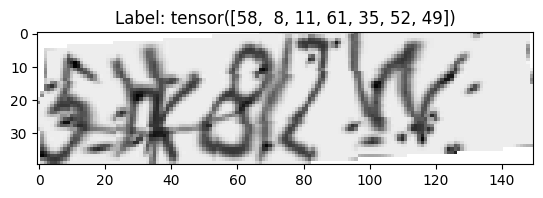

In [70]:
specific_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((40, 150)),
    RandomElasticTransform(alpha_range=(0.0, 100.0), sigma=9.0, fill=255),
    transforms.RandomAffine(
        degrees=(-5, 5), 
        fill=255
    ),
    transforms.ToTensor()
])

transformed_tensor = specific_transform(raw_image)
plt.imshow(transformed_tensor.squeeze(), cmap='gray')
plt.title(f"Label: {label}")
plt.show()